# Conditional Array Length Modeling

Tests whether Origami can learn **conditional** array length distributions — where array length depends on another field.

Mimics the GitHub IssueEvent pattern: `type` determines how likely an array is to be empty.

| type       | P(empty) | typical length |
|------------|----------|----------------|
| bug        | 80%      | 0-1            |
| feature    | 50%      | 0-3            |
| critical   | 10%      | 1-5            |

No explicit `length` field — the model must learn the conditional distribution from data.

Compare `numeric_mode="disabled"` (discrete tokens) vs `numeric_mode="scale"` (MoG + array length enforcement).

In [1]:
import random
from collections import Counter

import numpy as np

np.random.seed(42)
random.seed(42)

# Configuration
n_samples = 10_000

# Conditional array length distributions per type
# Each type has: P(empty), and a geometric distribution for non-empty lengths
type_configs = {
    "bug": {"p_empty": 0.80, "geo_p": 0.7, "max_len": 5},  # mostly empty, short when not
    "feature": {"p_empty": 0.50, "geo_p": 0.4, "max_len": 5},  # half empty, medium when not
    "critical": {"p_empty": 0.10, "geo_p": 0.3, "max_len": 5},  # rarely empty, longer
}
type_weights = {"bug": 0.5, "feature": 0.3, "critical": 0.2}  # type frequencies

assignees = ["alice", "bob", "carol", "dave", "eve"]
priorities = ["low", "medium", "high"]


def sample_array_length(type_name: str) -> int:
    cfg = type_configs[type_name]
    if random.random() < cfg["p_empty"]:
        return 0
    # Geometric distribution for non-empty, clamped to [1, max_len]
    length = min(np.random.geometric(cfg["geo_p"]), cfg["max_len"])
    return int(length)


# Generate dataset
types = random.choices(
    list(type_weights.keys()),
    weights=list(type_weights.values()),
    k=n_samples,
)

data = []
for t in types:
    length = sample_array_length(t)
    doc = {
        "type": t,
        "priority": random.choice(priorities),
        "assignees": random.sample(assignees, k=min(length, len(assignees))),
    }
    data.append(doc)

# Print conditional distributions
print("Conditional array length distributions:")
for t in type_configs:
    subset = [d for d in data if d["type"] == t]
    lens = [len(d["assignees"]) for d in subset]
    counts = Counter(lens)
    n = len(subset)
    p_empty = counts.get(0, 0) / n * 100
    mean_len = np.mean(lens)
    print(f"  {t:10s}: n={n:5d}, P(empty)={p_empty:5.1f}%, mean_len={mean_len:.2f}")
    for k in sorted(counts):
        pct = counts[k] / n * 100
        bar = "\u2588" * int(pct / 2)
        print(f"    len={k}: {counts[k]:4d} ({pct:5.1f}%) {bar}")

# Train/eval split
split = int(0.9 * n_samples)
train_data = data[:split]
eval_data = data[split:]

print(f"\nTrain: {len(train_data)}, Eval: {len(eval_data)}")
print(f"\nSample documents:")
for doc in data[:5]:
    print(f"  {doc}")

Conditional array length distributions:
  bug       : n= 4990, P(empty)= 80.4%, mean_len=0.28
    len=0: 4012 ( 80.4%) ████████████████████████████████████████
    len=1:  692 ( 13.9%) ██████
    len=2:  203 (  4.1%) ██
    len=3:   57 (  1.1%) 
    len=4:   18 (  0.4%) 
    len=5:    8 (  0.2%) 
  feature   : n= 3041, P(empty)= 49.4%, mean_len=1.15
    len=0: 1503 ( 49.4%) ████████████████████████
    len=1:  645 ( 21.2%) ██████████
    len=2:  345 ( 11.3%) █████
    len=3:  223 (  7.3%) ███
    len=4:  128 (  4.2%) ██
    len=5:  197 (  6.5%) ███
  critical  : n= 1969, P(empty)= 11.6%, mean_len=2.48
    len=0:  228 ( 11.6%) █████
    len=1:  509 ( 25.9%) ████████████
    len=2:  350 ( 17.8%) ████████
    len=3:  275 ( 14.0%) ██████
    len=4:  181 (  9.2%) ████
    len=5:  426 ( 21.6%) ██████████

Train: 9000, Eval: 1000

Sample documents:
  {'type': 'feature', 'priority': 'high', 'assignees': ['alice']}
  {'type': 'bug', 'priority': 'low', 'assignees': []}
  {'type': 'bug', 'priorit

## Train with `numeric_mode="disabled"` (baseline)

In [2]:
from origami import InferenceConfig, ModelConfig, OrigamiConfig, OrigamiPipeline, TrainingConfig
from origami.config import DataConfig
from origami.training import TableLogCallback

shared_model = ModelConfig(
    backbone="transformer",
    kvpe_pooling="sum",
    d_model=64,
    n_heads=8,
    n_layers=6,
    d_ff=784,
    dropout=0.0,
    num_mixture_components=10,
)

shared_training = TrainingConfig(
    shuffle_keys=True,
    batch_size=64,
    warmup_steps=500,
    learning_rate=5e-4,
    constrain_grammar=True,
    constrain_schema=True,
    eval_strategy="steps",
    eval_steps=100,
)

n_epochs = 30

In [3]:
config_disabled = OrigamiConfig(
    data=DataConfig(infer_schema=True, numeric_mode="disabled"),
    model=shared_model,
    training=shared_training,
    inference=InferenceConfig(constrain_grammar=True, constrain_schema=True),
    device="mps",
)

pipeline_disabled = OrigamiPipeline(config_disabled)
pipeline_disabled.fit(
    train_data,
    eval_data=eval_data,
    callbacks=[TableLogCallback(print_every=100)],
    epochs=n_epochs,
    verbose=True,
)

Numba available: False
Infer schema: True
Vocabulary size: 24
Model parameters: 728,184
Training device: mps
| step: 100 | epoch: 0 | lr: 1.00e-04 | batch_dt:  16ms | loss: 0.6227 | val_loss: 0.6376 |
| step: 200 | epoch: 1 | lr: 2.00e-04 | batch_dt:  17ms | loss: 0.5415 | val_loss: 0.5148 |
| step: 300 | epoch: 2 | lr: 3.00e-04 | batch_dt:  44ms | loss: 0.5439 | val_loss: 0.5250 |
| step: 400 | epoch: 2 | lr: 4.00e-04 | batch_dt:  42ms | loss: 0.4879 | val_loss: 0.5222 |
| step: 500 | epoch: 3 | lr: 4.40e-04 | batch_dt:  20ms | loss: 0.4900 | val_loss: 0.5250 |
| step: 600 | epoch: 4 | lr: 4.29e-04 | batch_dt:  18ms | loss: 0.4966 | val_loss: 0.4960 |
| step: 700 | epoch: 4 | lr: 4.17e-04 | batch_dt:  19ms | loss: 0.4996 | val_loss: 0.4999 |
| step: 800 | epoch: 5 | lr: 4.05e-04 | batch_dt:  19ms | loss: 0.4427 | val_loss: 0.5023 |
| step: 900 | epoch: 6 | lr: 3.93e-04 | batch_dt:  19ms | loss: 0.5209 | val_loss: 0.4922 |
| step: 1000 | epoch: 7 | lr: 3.81e-04 | batch_dt:  29ms | loss

OrigamiPipeline(numeric_mode='disabled', fitted)

## Train with `numeric_mode="scale"` (MoG + array length enforcement)

In [4]:
config_scale = OrigamiConfig(
    data=DataConfig(infer_schema=True, numeric_mode="scale"),
    model=shared_model,
    training=shared_training,
    inference=InferenceConfig(constrain_grammar=True, constrain_schema=True),
    device="mps",
)

pipeline_scale = OrigamiPipeline(config_scale)
pipeline_scale.fit(
    train_data,
    eval_data=eval_data,
    callbacks=[TableLogCallback(print_every=100)],
    epochs=n_epochs,
    verbose=True,
)

Infer schema: True
Vocabulary size: 24
Model parameters: 730,198
Training device: mps
| step: 100 | epoch: 0 | lr: 1.00e-04 | batch_dt:  21ms | loss: 0.6868 | val_loss: 0.7356 |
| step: 200 | epoch: 1 | lr: 2.00e-04 | batch_dt:  39ms | loss: 0.6045 | val_loss: 0.6120 |
| step: 300 | epoch: 2 | lr: 3.00e-04 | batch_dt:  22ms | loss: 0.6710 | val_loss: 0.6171 |
| step: 400 | epoch: 2 | lr: 4.00e-04 | batch_dt:  79ms | loss: 0.5896 | val_loss: 0.5899 |
| step: 500 | epoch: 3 | lr: 4.40e-04 | batch_dt:  52ms | loss: 0.5769 | val_loss: 0.5775 |
| step: 600 | epoch: 4 | lr: 4.29e-04 | batch_dt:  46ms | loss: 0.5818 | val_loss: 0.5700 |
| step: 700 | epoch: 4 | lr: 4.17e-04 | batch_dt:  22ms | loss: 0.5446 | val_loss: 0.5734 |
| step: 800 | epoch: 5 | lr: 4.05e-04 | batch_dt:  22ms | loss: 0.6111 | val_loss: 0.5587 |
| step: 900 | epoch: 6 | lr: 3.93e-04 | batch_dt:  21ms | loss: 0.5374 | val_loss: 0.5640 |
| step: 1000 | epoch: 7 | lr: 3.81e-04 | batch_dt:  23ms | loss: 0.5881 | val_loss: 0.

OrigamiPipeline(numeric_mode='scale', fitted)

## Generate and Compare

In [5]:
import matplotlib.pyplot as plt

n_gen = 10_000


def analyze_generated(generated, label):
    """Extract per-type array length stats from generated samples."""
    valid = [d for d in generated if "assignees" in d and "type" in d]
    print(f"\n{label}: {len(valid)}/{len(generated)} valid samples")
    for doc in generated[:3]:
        print(f"  {doc}")

    stats = {}
    for t in type_configs:
        subset = [d for d in valid if d["type"] == t]
        if not subset:
            stats[t] = {"n": 0, "p_empty": 0, "mean_len": 0, "length_dist": {}}
            continue
        lens = [len(d["assignees"]) for d in subset]
        counts = Counter(lens)
        n = len(subset)
        stats[t] = {
            "n": n,
            "p_empty": counts.get(0, 0) / n,
            "mean_len": np.mean(lens),
            "length_dist": {k: counts.get(k, 0) / n for k in range(max(lens) + 1)},
        }
    return stats


# Get training data stats
train_stats = {}
for t in type_configs:
    subset = [d for d in train_data if d["type"] == t]
    lens = [len(d["assignees"]) for d in subset]
    counts = Counter(lens)
    n = len(subset)
    train_stats[t] = {
        "n": n,
        "p_empty": counts.get(0, 0) / n,
        "mean_len": np.mean(lens),
        "length_dist": {k: counts.get(k, 0) / n for k in range(max(lens) + 1)},
    }

# Generate from both models
gen_disabled = pipeline_disabled.generate(num_samples=n_gen, temperature=1.0)
gen_scale = pipeline_scale.generate(num_samples=n_gen, temperature=1.0)

stats_disabled = analyze_generated(gen_disabled, "disabled")
stats_scale = analyze_generated(gen_scale, "scale")


disabled: 10000/10000 valid samples
  {'priority': 'high', 'assignees': ['dave'], 'type': 'bug'}
  {'priority': 'high', 'assignees': ['bob', 'eve', 'dave', 'carol'], 'type': 'feature'}
  {'priority': 'low', 'assignees': ['eve'], 'type': 'critical'}

scale: 10000/10000 valid samples
  {'priority': 'low', 'assignees': [], 'type': 'feature'}
  {'priority': 'low', 'assignees': ['dave'], 'type': 'bug'}
  {'assignees': [], 'type': 'feature', 'priority': 'medium'}


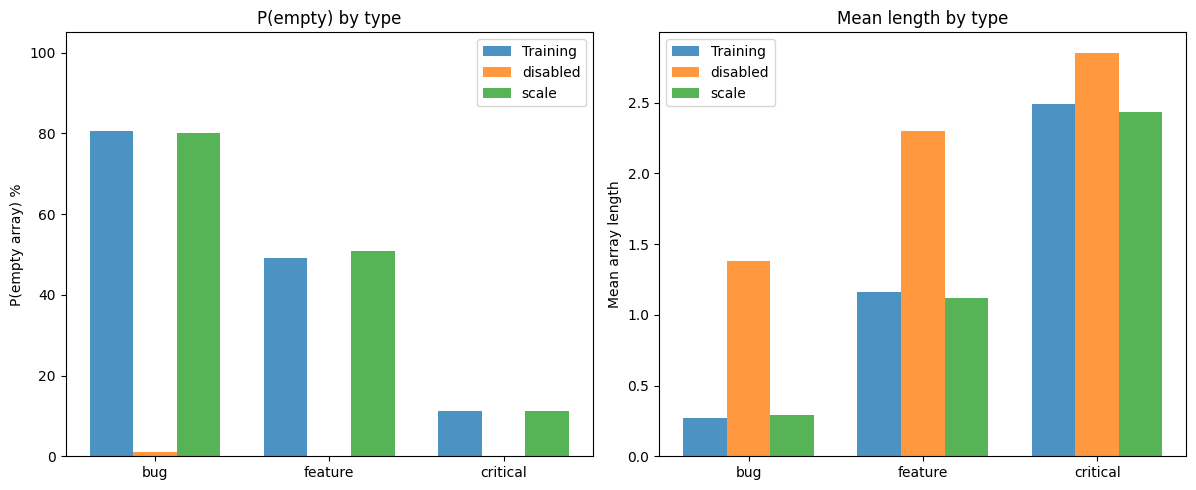

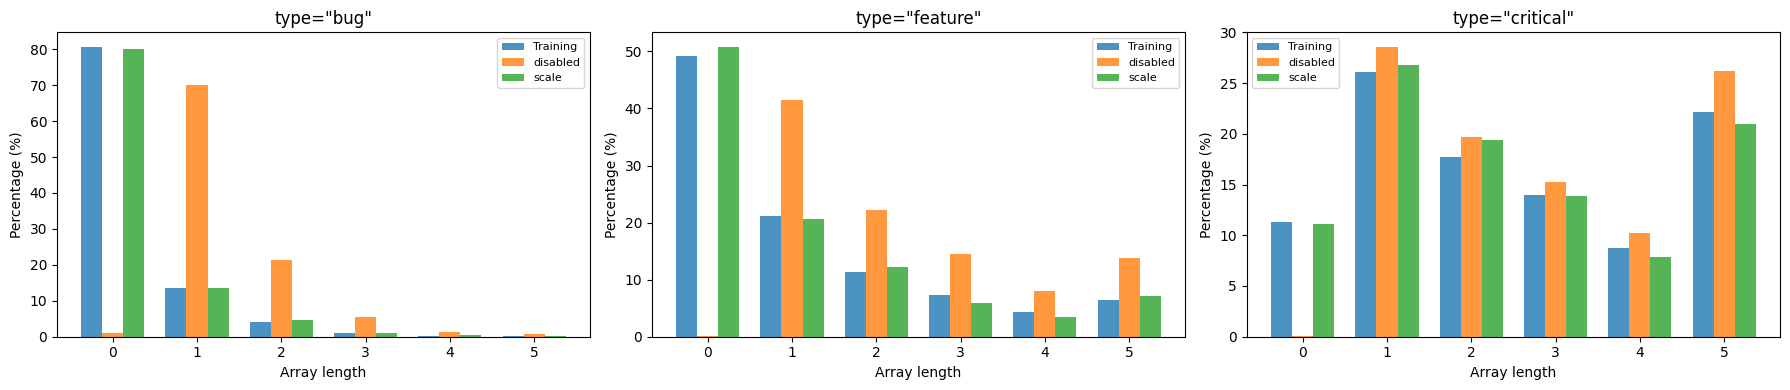


      type | P(empty) train | P(empty) disabled | P(empty) scale | mean train | mean disabled | mean scale
----------------------------------------------------------------------------------------------------
       bug |         80.7% |             1.0% |         80.0% |       0.27 |          1.38 |       0.29
   feature |         49.2% |             0.2% |         50.8% |       1.16 |          2.30 |       1.12
  critical |         11.3% |             0.1% |         11.1% |       2.49 |          2.86 |       2.44


In [6]:
# --- Plot: Per-type P(empty) comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

type_names = list(type_configs.keys())
x = np.arange(len(type_names))
width = 0.25

# Plot 1: P(empty) per type
train_empty = [train_stats[t]["p_empty"] * 100 for t in type_names]
disabled_empty = [stats_disabled[t]["p_empty"] * 100 for t in type_names]
scale_empty = [stats_scale[t]["p_empty"] * 100 for t in type_names]

axes[0].bar(x - width, train_empty, width, label="Training", alpha=0.8)
axes[0].bar(x, disabled_empty, width, label="disabled", alpha=0.8)
axes[0].bar(x + width, scale_empty, width, label="scale", alpha=0.8)
axes[0].set_ylabel("P(empty array) %")
axes[0].set_title("P(empty) by type")
axes[0].set_xticks(x)
axes[0].set_xticklabels(type_names)
axes[0].legend()
axes[0].set_ylim(0, 105)

# Plot 2: Mean array length per type
train_mean = [train_stats[t]["mean_len"] for t in type_names]
disabled_mean = [stats_disabled[t]["mean_len"] for t in type_names]
scale_mean = [stats_scale[t]["mean_len"] for t in type_names]

axes[1].bar(x - width, train_mean, width, label="Training", alpha=0.8)
axes[1].bar(x, disabled_mean, width, label="disabled", alpha=0.8)
axes[1].bar(x + width, scale_mean, width, label="scale", alpha=0.8)
axes[1].set_ylabel("Mean array length")
axes[1].set_title("Mean length by type")
axes[1].set_xticks(x)
axes[1].set_xticklabels(type_names)
axes[1].legend()

# Plot 3: Full length distribution for each type (stacked subplots)
max_display_len = 6
lens_x = np.arange(max_display_len)
bar_w = 0.25

# Use the third axes area for a grouped comparison of all types
axes[2].set_visible(False)

plt.tight_layout()
plt.show()

# --- Detailed per-type length distributions ---
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for idx, t in enumerate(type_names):
    ax = axes2[idx]
    for _src, stats, label in [
        (train_stats, train_stats, "Training"),
        (stats_disabled, stats_disabled, "disabled"),
        (stats_scale, stats_scale, "scale"),
    ]:
        dist = stats[t]["length_dist"]
        lengths = sorted(dist.keys())
        lengths = [length for length in lengths if length < max_display_len]
        pcts = [dist.get(length, 0) * 100 for length in lengths]
        offset = {"Training": -bar_w, "disabled": 0, "scale": bar_w}[label]
        ax.bar([length + offset for length in lengths], pcts, bar_w, label=label, alpha=0.8)
    ax.set_xlabel("Array length")
    ax.set_ylabel("Percentage (%)")
    ax.set_title(f'type="{t}"')
    ax.set_xticks(range(max_display_len))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Summary table ---
print(
    f"\n{'type':>10s} | {'P(empty) train':>14s} | {'P(empty) disabled':>17s} | {'P(empty) scale':>14s} | {'mean train':>10s} | {'mean disabled':>13s} | {'mean scale':>10s}"
)
print("-" * 100)
for t in type_names:
    print(
        f"{t:>10s} | {train_stats[t]['p_empty']:>13.1%} | {stats_disabled[t]['p_empty']:>16.1%} | {stats_scale[t]['p_empty']:>13.1%} | "
        f"{train_stats[t]['mean_len']:>10.2f} | {stats_disabled[t]['mean_len']:>13.2f} | {stats_scale[t]['mean_len']:>10.2f}"
    )